 *Artificial Intelligence for Vision & NLP* &nbsp; | &nbsp;  *ATU Donegal - Postgrad Diploma in Big Data Analytics & Artificial Intelligence*

# Student Submisison 
Name           : Tomas Wynne                <br>
Student Number : L00196526                  <br>
Due Date       : 12th May 2026              <br>
Assignment     : CA2                        <br>
Module         : AI for Vision and NLP      <br>
Course         : Postgraduate Diploma in Big Data Analytics and AI

## NLP and Vision Pipeline : High Level
An image of your working pipeline at high level can be inserted here



# Initialisation
Perform pip installs(or use a requirements.txt) <br>
perform imports

## Install packages

In [ ]:
%pip install -r requirements.txt
!python -m spacy download en_core_web_sm


Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 26.1 -> 26.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


     ---------------------------------------- 0.0/12.8 MB ? eta -:--:--
     ---------------------------------------- 12.8/12.8 MB 90.1 MB/s  0:00:00
✔ Download and installation successful
You can now load the package via spacy.load('en_core_web_sm')



[notice] A new release of pip is available: 26.1 -> 26.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


## Imports

In [31]:
# imports

#import sys
#print(sys.executable)

#import os
#import site
#print(site.getusersitepackages())
import cv2
import pymupdf
import json

import numpy as np
import spacy
from sklearn.feature_extraction.text import TfidfVectorizer

import matplotlib.pyplot as plt
# allows inline plotting
%matplotlib inline
# Setting global params for matplotlib
plt.rcParams['figure.figsize'] = (20, 20)

import pytesseract
from pytesseract import Output
# Tesseract Path
pytesseract.pytesseract.tesseract_cmd = r"C:\Program Files\Tesseract-OCR\tesseract.exe"

# regular expression
import re

# Load NLP model
nlp = spacy.load("en_core_web_sm")

# Support Functions

In [32]:
# code here

def load_pdf(filename):
    doc = pymupdf.open(filename)

    # if the pdf ad multiple pages this for loop can be edited to accommodate
    for page in doc:
        # setting the dpi to 200 for higher quality image - this can be set higher
        new_image = page.get_pixmap(dpi=400)
    # Saving the image to local drive where it can be accessed again
    filename = filename.replace(".pdf", ".jpg")
    new_image.save(filename)
    return load_image(filename)

def load_image(path):
    image = cv2.imread(path)
    if image is None:
        raise ValueError("Image not found. Check file path.")
    image_rgb = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
    return image, image_rgb

def preprocess_image(image):
        # Convert to grayscale
    gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)
    blur = cv2.GaussianBlur(gray,(3,3),10)
    thresh = cv2.adaptiveThreshold(blur,255,cv2.ADAPTIVE_THRESH_MEAN_C,cv2.THRESH_BINARY_INV,11,8)
    return gray, blur, thresh

 # Makes a token out of the lemma of every word in the document that is not a stop word, punctuation or a space
def preprocess_text(text):
    document = nlp(text)
    tokens = []

    for token in document:
        if not token.is_stop and not token.is_punct and not token.is_space:
            tokens.append(token.lemma_.lower())
    return tokens, document

# Returns Named Entities
def get_entities(doc):
    entities = []
    for ent in doc.ents:
        entities.append((ent.text, ent.label_))
    return entities

def get_tfidf(text):
    vectorizer = TfidfVectorizer()
    tfidf_matrix = vectorizer.fit_transform([text])
    feature_names = vectorizer.get_feature_names_out()
    scores = tfidf_matrix.toarray()[0]
    return list(zip(feature_names, scores))

# NLP

## Sub Heading 1

In [29]:
## code

# Take in first image
image, image_rgb = load_image("Blue Prince Screenshot.png")

# Display image
#plt.imshow(image_rgb)
#plt.title("Testdoc1 - Original Image")
#plt.axis("off")

# Display Raw Text, added preprocessing to make it cleaner
#text = pytesseract.image_to_string(image)
#print(text)

# Preprocess the image (greyscale and binary thresh)
gray, blur, thresh = preprocess_image(image)

# OCR Extraction and display processed text
text = pytesseract.image_to_string(thresh)
print(text)

# Process the text, returns clean tokens and document object of text
tokens, document = preprocess_text(text)

print("\n--- First 50 Tokens ---\n")
print(tokens[:50])

# Returns named entities from the document
entities = get_entities(document)
print("\n--- Named Entities ---\n")
for ent_text, ent_label in entities:
    print(f"{ent_text}: {ent_label}")

# Returns weighted tokens which are sorted to display the most important tokens.
clean_text = " ".join(tokens)
features = get_tfidf(clean_text)
top_features = sorted(features, key=lambda x: x[1], reverse=True)[:15]

print("\n--- Top TF-IDF Features ---\n")
for word, score in top_features:
    print(f"{word}: {score:.4f}")

results = {
    "raw_text": text,
    "clean_tokens": tokens,
    "named_entities": entities,
    "top_keywords": [
        {
            "word": word,
            "score": float(score)
        }
        for word, score in top_features
    ]
}

with open("blueprince_results.json", "w") as file:
    json.dump(results, file, indent=4)

print("\nResults exported to blueprince_results.json")

Sf YK SN Wt —_—--

THE SOIL SURVEY

One of the first tasks I undertook as groundskeeper was

to conduct a survey of the various plots of soil underneath
each slot on both the East and West Wings of the house.
And while I would have preferred a full survey of all forty-
five plots of the house, it was clear that the inconvenience
such an undertaking would produce was in no way worth
the extra data, especially considering the rooms that would

benefit from this survey only ever appear in the wings.

To quantify soil quality, I measured the soil’s capacity to
support crop growth and maximize the promise of high

yields. The survey ended up taking two weeks due to some | | | my

difficulty reaching the higher ranks but the project was well ia || ; 4 FOOR

worth the effort. As suspected, the room position has a

direct relationship to the amount of fruit spread from <x] | | [ | [ | GOOD

gardens and the amount of flowers that can bloom in a a = SOIL

Greenhouse. Ll | [| RICH
| | _ Lo SOIL



In [33]:

# Take in first image
image, image_rgb = load_pdf("Using_Behavioural_Skills_Training_with_Healthcare_page_2.pdf")

# Display image
#plt.imshow(image_rgb)
#plt.title("Testdoc1 - Original Image")
#plt.axis("off")

# Display Raw Text, added preprocessing to make it cleaner
#text = pytesseract.image_to_string(image)
#print(text)

# Preprocess the image (greyscale and binary thresh)
gray, blur, thresh = preprocess_image(image)

# OCR Extraction and display processed text
text = pytesseract.image_to_string(thresh)
print(text)

# Process the text, returns clean tokens and document object of text
tokens, document = preprocess_text(text)

print("\n--- First 50 Tokens ---\n")
print(tokens[:50])

# Returns named entities from the document
entities = get_entities(document)
print("\n--- Named Entities ---\n")
for ent_text, ent_label in entities:
    print(f"{ent_text}: {ent_label}")

# Returns weighted tokens which are sorted to display the most important tokens.
clean_text = " ".join(tokens)
features = get_tfidf(clean_text)
top_features = sorted(features, key=lambda x: x[1], reverse=True)[:15]

print("\n--- Top TF-IDF Features ---\n")
for word, score in top_features:
    print(f"{word}: {score:.4f}")

results = {
    "raw_text": text,
    "clean_tokens": tokens,
    "named_entities": entities,
    "top_keywords": [
        {
            "word": word,
            "score": float(score)
        }
        for word, score in top_features
    ]
}

with open("behavioural_results.json", "w") as file:
    json.dump(results, file, indent=4)

print("\nResults exported to behavioural_results.json")

Behav. Sci. 2025, 15, 870

8 of 21

intervention for P3 and P1 and a level trend at baseline and an increasing therapeutic trend
during the intervention for P2. A stability envelope was applied to trend lines and showed
that the data were stable at baseline for P3 but variable during the intervention, while
data were stable in both phases for P1 and P2. P3’s mean accuracy scores increased from
51.67% at baseline (range 55-45%) to 83.33% (range 100-65%) during the intervention, and
maintenance was 100%. P1’s mean accuracy scores increased from 36.8% (range 45-35%)
at baseline to 80% (range 100-65%) during the intervention, and maintenance was 100%.
P2’s mean accuracy scores increased from 40.71% (range 45-35%) at baseline to 82% (range
85-65%) during the intervention, and maintenance was 75%.

Between-Condition Analysis: Evaluation of the behaviour change between conditions
indicated improvements for the intervention relative to the baseline for all three partic-
ipants. For P2, a chang

## Not used yet

In [ ]:
# Take in first image
image, image_rgb = load_image("Blue Prince Screenshot.png")

# Display image
#plt.imshow(image_rgb)
#plt.title("Testdoc1 - Original Image")
#plt.axis("off")

# Display Raw Text, added preprocessing to make it cleaner
#text = pytesseract.image_to_string(image)
#print(text)

# Preprocess the image (greyscale and binary thresh)
gray, blur, thresh = preprocess_image(image)

# OCR Extraction and display processed text
text = pytesseract.image_to_string(thresh)
print(text)

# Process the text, returns clean tokens and document object of text
tokens, document = preprocess_text(text)

print("\n--- First 50 Tokens ---\n")
print(tokens[:50])

# Returns named entities from the document
entities = get_entities(document)
print("\n--- Named Entities ---\n")
for ent_text, ent_label in entities:
    print(f"{ent_text}: {ent_label}")

# Returns weighted tokens which are sorted to display the most important tokens.
clean_text = " ".join(tokens)
features = get_tfidf(clean_text)
top_features = sorted(features, key=lambda x: x[1], reverse=True)[:15]

print("\n--- Top TF-IDF Features ---\n")
for word, score in top_features:
    print(f"{word}: {score:.4f}")

results = {
    "raw_text": text,
    "clean_tokens": tokens,
    "named_entities": entities,
    "top_keywords": [
        {
            "word": word,
            "score": float(score)
        }
        for word, score in top_features
    ]
}

with open("blueprince_results.json", "w") as file:
    json.dump(results, file, indent=4)

print("\nResults exported to blueprince_results.json")

# Vision

## Sub Heading 1

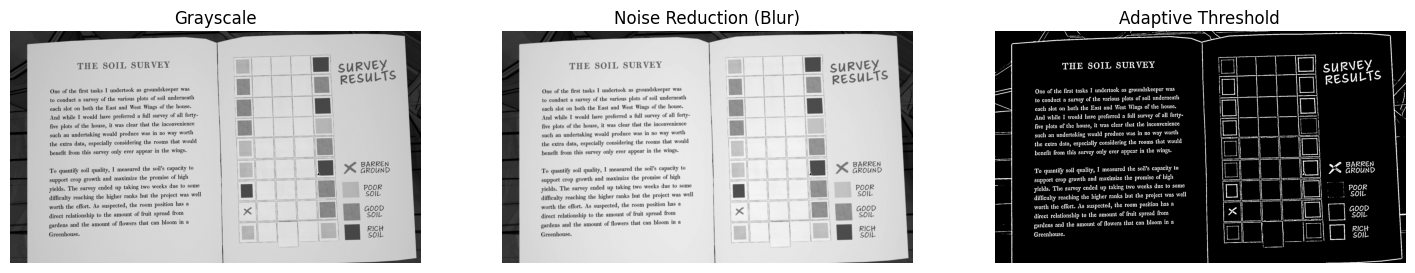

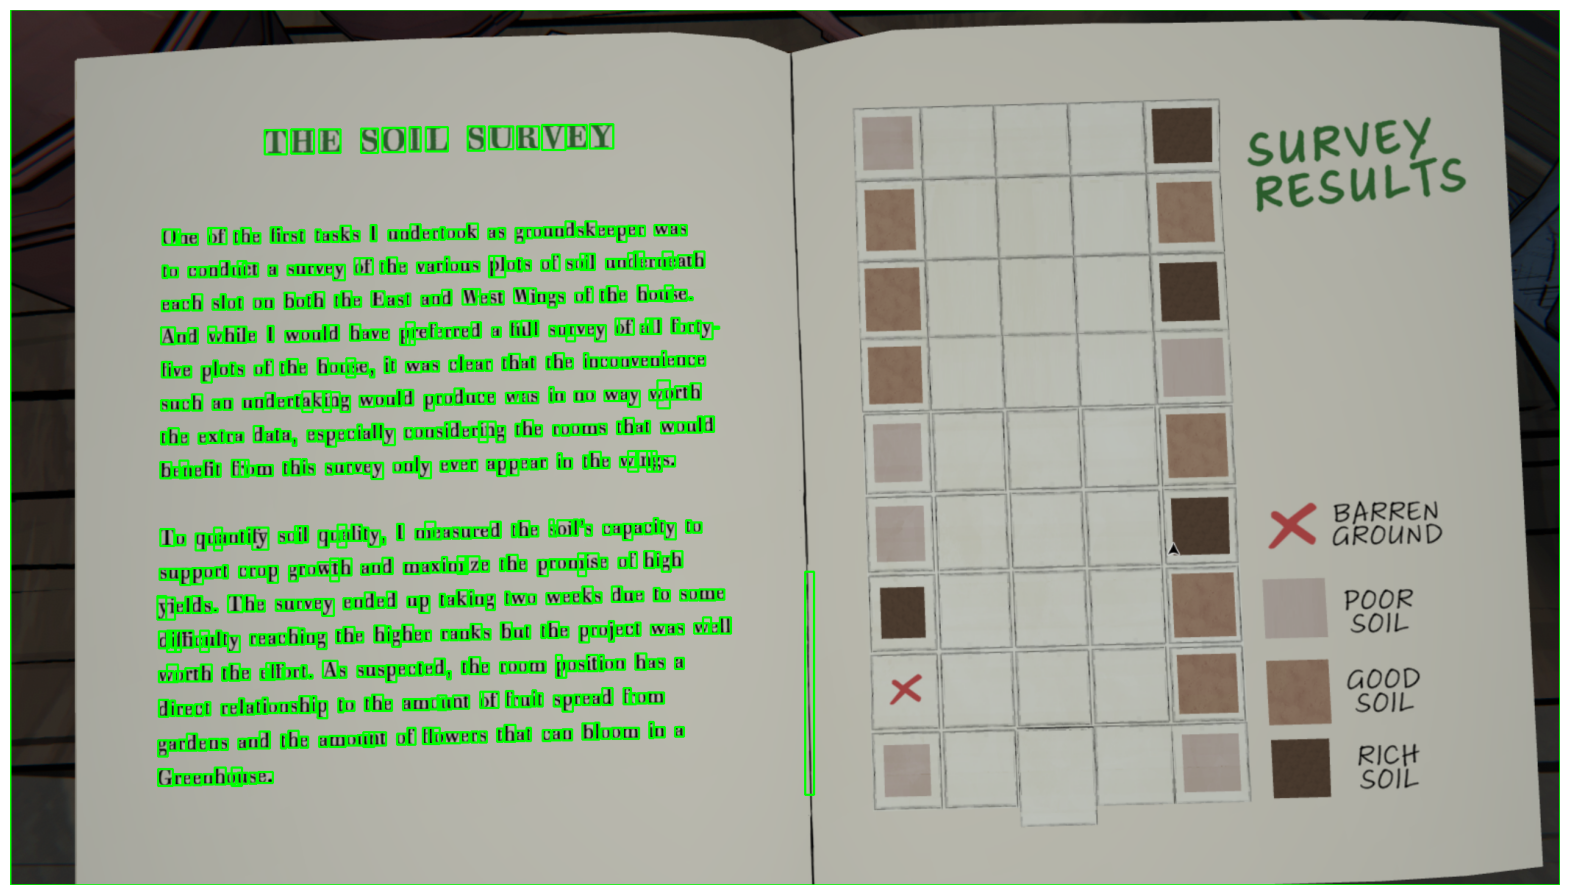

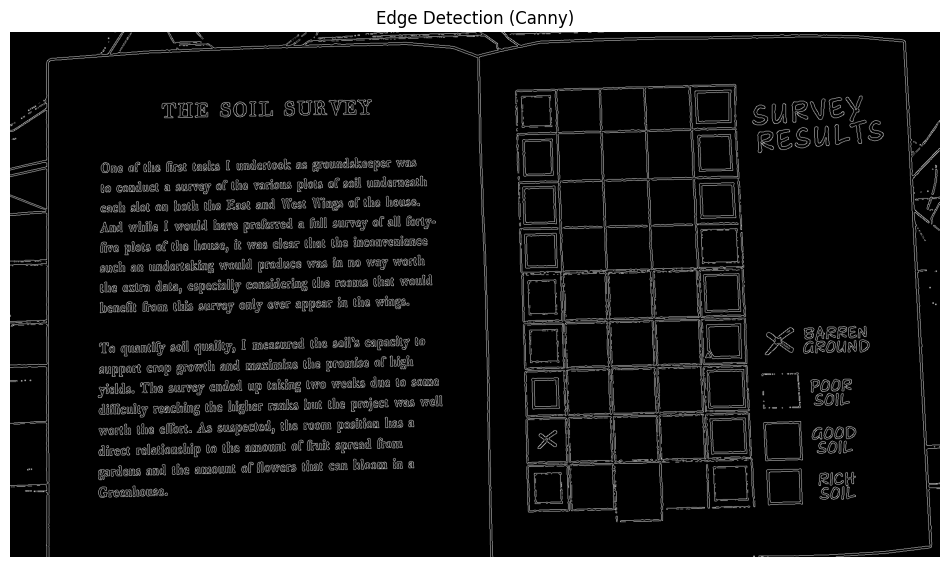


Number of contours detected: 3096


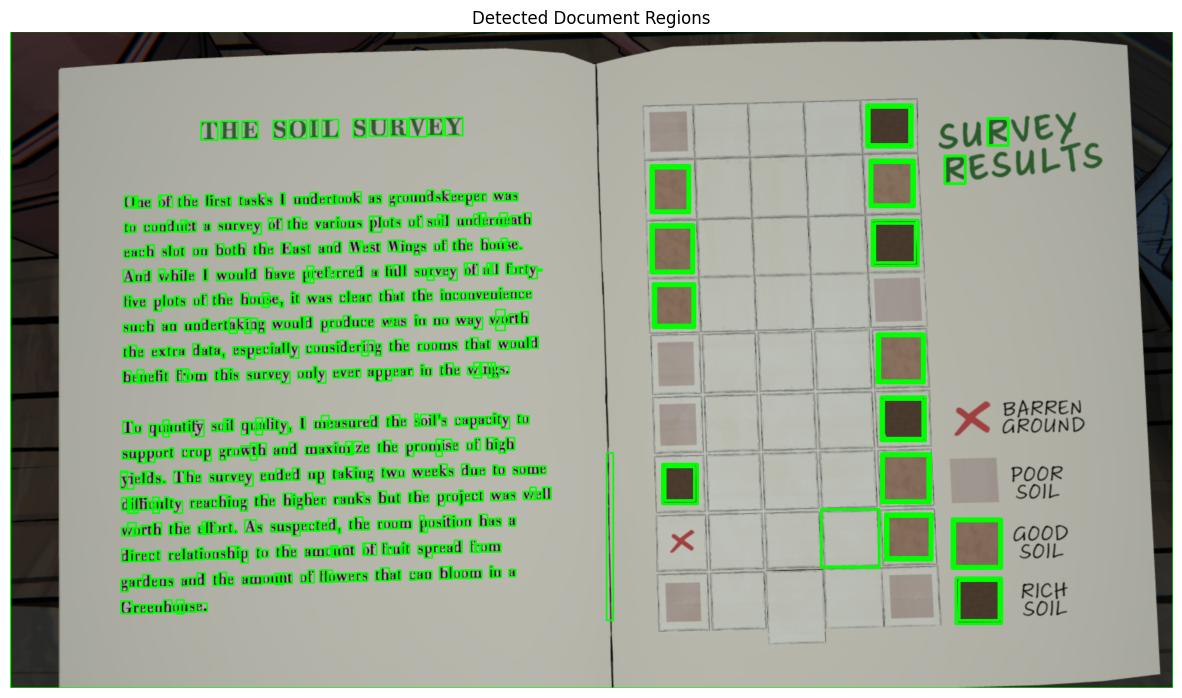

In [17]:
# code here...

# Display image
plt.figure(figsize=(18,6))

# Grayscale
plt.subplot(1,3,1)
plt.imshow(gray, cmap='gray')
plt.title("Grayscale")
plt.axis("off")

# Blurred
plt.subplot(1,3,2)
plt.imshow(blur, cmap='gray')
plt.title("Noise Reduction (Blur)")
plt.axis("off")

# Thresholded
plt.subplot(1,3,3)
plt.imshow(thresh, cmap='gray')
plt.title("Adaptive Threshold")
plt.axis("off")

plt.show()

h, w, c = image_rgb.shape
boxes = pytesseract.image_to_boxes(image_rgb)
for b in boxes.splitlines():
    b = b.split(' ')
    image_boxed = cv2.rectangle(image_rgb, (int(b[1]), h - int(b[2])), (int(b[3]), h - int(b[4])), (0, 255, 0), 2) #OpenCV is in Blue, Green, Red format.

plt.imshow(image_boxed)
plt.axis("off")
plt.show()

# Detect edges in image
edges = cv2.Canny(thresh, 50, 150)

# Display edges
plt.figure(figsize=(12,12))
plt.imshow(edges, cmap='gray')
plt.title("Edge Detection (Canny)")
plt.axis("off")
plt.show()

# Find contours from edge image
contours, hierarchy = cv2.findContours(
    edges,
    cv2.RETR_TREE,
    cv2.CHAIN_APPROX_SIMPLE
)

print(f"\nNumber of contours detected: {len(contours)}")

# Create copy for drawing
contour_image = image_rgb.copy()

# Loop through contours
for contour in contours:

    # Ignore tiny contours
    area = cv2.contourArea(contour)

    if area > 1000:

        # Get bounding rectangle
        x, y, w, h = cv2.boundingRect(contour)

        # Draw rectangle
        cv2.rectangle(
            contour_image,
            (x, y),
            (x + w, y + h),
            (0, 255, 0),
            3
        )

# Display detected regions
plt.figure(figsize=(15,15))
plt.imshow(contour_image)
plt.title("Detected Document Regions")
plt.axis("off")
plt.show()

# Multi-modal

## Sub Heading 1

In [18]:
# code here

# Final Output

In [19]:
# code